In [ ]:
text/IMDB Dataset.csvtext/IMDB Dataset.csv

In [162]:
import pandas as pd

In [224]:
df=pd.read_csv('IMDB Dataset.csv')

In [225]:
df['review'][0]

"One of the other reviewers has mentioned that after watching just 1 Oz episode you'll be hooked. They are right, as this is exactly what happened with me.<br /><br />The first thing that struck me about Oz was its brutality and unflinching scenes of violence, which set in right from the word GO. Trust me, this is not a show for the faint hearted or timid. This show pulls no punches with regards to drugs, sex or violence. Its is hardcore, in the classic use of the word.<br /><br />It is called OZ as that is the nickname given to the Oswald Maximum Security State Penitentary. It focuses mainly on Emerald City, an experimental section of the prison where all the cells have glass fronts and face inwards, so privacy is not high on the agenda. Em City is home to many..Aryans, Muslims, gangstas, Latinos, Christians, Italians, Irish and more....so scuffles, death stares, dodgy dealings and shady agreements are never far away.<br /><br />I would say the main appeal of the show is due to the fa

In [226]:
# cleaning data 


In [227]:
df.duplicated().sum()

np.int64(418)

In [228]:
df.drop_duplicates()

,review,sentiment
0,One of the other reviewers has mentioned that ...,positive
1,A wonderful little production. <br /><br />The...,positive
2,I thought this was a wonderful way to spend ti...,positive
3,Basically there's a family where a little boy ...,negative
4,"Petter Mattei's ""Love in the Time of Money"" is...",positive
...,...,...
49995,I thought this movie did a down right good job...,positive
49996,"Bad plot, bad dialogue, bad acting, idiotic di...",negative
49997,I am a Catholic taught in parochial elementary...,negative
49998,I'm going to have to disagree with the previou...,negative


In [229]:
df['review']=df['review'].str.lower()

In [230]:
df

,review,sentiment
0,one of the other reviewers has mentioned that ...,positive
1,a wonderful little production. <br /><br />the...,positive
2,i thought this was a wonderful way to spend ti...,positive
3,basically there's a family where a little boy ...,negative
4,"petter mattei's ""love in the time of money"" is...",positive
...,...,...
49995,i thought this movie did a down right good job...,positive
49996,"bad plot, bad dialogue, bad acting, idiotic di...",negative
49997,i am a catholic taught in parochial elementary...,negative
49998,i'm going to have to disagree with the previou...,negative


In [231]:
import re

def clean_review(text):
    text = str(text)

    # Remove HTML tags
    text = re.sub(r'<[^>]*>', ' ', text)

    # Remove numbers
    text = re.sub(r'\d+', ' ', text)

    # Keep letters, spaces, apostrophe (') and period (.)
    text = re.sub(r"[^a-zA-Z\s'.]", ' ', text)

    # Remove extra spaces
    text = re.sub(r'\s+', ' ', text).strip()

    # Convert to lowercase
    text = text.lower()

    return text

df['clean_review'] = df['review'].apply(clean_review)

In [232]:
df['clean_review'][0]

"one of the other reviewers has mentioned that after watching just oz episode you'll be hooked. they are right as this is exactly what happened with me. the first thing that struck me about oz was its brutality and unflinching scenes of violence which set in right from the word go. trust me this is not a show for the faint hearted or timid. this show pulls no punches with regards to drugs sex or violence. its is hardcore in the classic use of the word. it is called oz as that is the nickname given to the oswald maximum security state penitentary. it focuses mainly on emerald city an experimental section of the prison where all the cells have glass fronts and face inwards so privacy is not high on the agenda. em city is home to many..aryans muslims gangstas latinos christians italians irish and more....so scuffles death stares dodgy dealings and shady agreements are never far away. i would say the main appeal of the show is due to the fact that it goes where other shows wouldn't dare. f

In [233]:
df

,review,sentiment,clean_review
0,one of the other reviewers has mentioned that ...,positive,one of the other reviewers has mentioned that ...
1,a wonderful little production. <br /><br />the...,positive,a wonderful little production. the filming tec...
2,i thought this was a wonderful way to spend ti...,positive,i thought this was a wonderful way to spend ti...
3,basically there's a family where a little boy ...,negative,basically there's a family where a little boy ...
4,"petter mattei's ""love in the time of money"" is...",positive,petter mattei's love in the time of money is a...
...,...,...,...
49995,i thought this movie did a down right good job...,positive,i thought this movie did a down right good job...
49996,"bad plot, bad dialogue, bad acting, idiotic di...",negative,bad plot bad dialogue bad acting idiotic direc...
49997,i am a catholic taught in parochial elementary...,negative,i am a catholic taught in parochial elementary...
49998,i'm going to have to disagree with the previou...,negative,i'm going to have to disagree with the previou...


In [234]:
df=df.drop(columns='review')

In [235]:
df

,sentiment,clean_review
0,positive,one of the other reviewers has mentioned that ...
1,positive,a wonderful little production. the filming tec...
2,positive,i thought this was a wonderful way to spend ti...
3,negative,basically there's a family where a little boy ...
4,positive,petter mattei's love in the time of money is a...
...,...,...
49995,positive,i thought this movie did a down right good job...
49996,negative,bad plot bad dialogue bad acting idiotic direc...
49997,negative,i am a catholic taught in parochial elementary...
49998,negative,i'm going to have to disagree with the previou...


In [236]:
# expand 

def remove_abb(data):
    data = re.sub(r"hes", "he is", data)
    data = re.sub(r"who'll","who will",data)
    data = re.sub(r"there's", "there is", data)
    data = re.sub(r"We're", "We are", data)
    data = re.sub(r"That's", "That is", data)
    data = re.sub(r"won't", "will not", data)
    data = re.sub(r"they're", "they are", data)
    data = re.sub(r"Can't", "Cannot", data)
    data = re.sub(r"wasn't", "was not", data)
    data = re.sub(r"don\x89Ûªt", "do not", data)
    data= re.sub(r"aren't", "are not", data)
    data = re.sub(r"isn't", "is not", data)
    data = re.sub(r"What's", "What is", data)
    data = re.sub(r"haven't", "have not", data)
    data = re.sub(r"hasn't", "has not", data)
    data = re.sub(r"There's", "There is", data)
    data = re.sub(r"He's", "He is", data)
    data = re.sub(r"It's", "It is", data)
    data = re.sub(r"You're", "You are", data)
    data = re.sub(r"I'M", "I am", data)
    data = re.sub(r"shouldn't", "should not", data)
    data = re.sub(r"wouldn't", "would not", data)
    data = re.sub(r"i'm", "I am", data)
    data = re.sub(r"I\x89Ûªm", "I am", data)
    data = re.sub(r"I'm", "I am", data)
    data = re.sub(r"Isn't", "is not", data)
    data = re.sub(r"Here's", "Here is", data)
    data = re.sub(r"you've", "you have", data)
    data = re.sub(r"you\x89Ûªve", "you have", data)
    data = re.sub(r"we're", "we are", data)
    data = re.sub(r"what's", "what is", data)
    data = re.sub(r"couldn't", "could not", data)
    data = re.sub(r"we've", "we have", data)
    data = re.sub(r"it\x89Ûªs", "it is", data)
    data = re.sub(r"doesn\x89Ûªt", "does not", data)
    data = re.sub(r"It\x89Ûªs", "It is", data)
    data = re.sub(r"Here\x89Ûªs", "Here is", data)
    data = re.sub(r"who's", "who is", data)
    data = re.sub(r"I\x89Ûªve", "I have", data)
    data = re.sub(r"y'all", "you all", data)
    data = re.sub(r"can\x89Ûªt", "cannot", data)
    data = re.sub(r"would've", "would have", data)
    data = re.sub(r"it'll", "it will", data)
    data = re.sub(r"we'll", "we will", data)
    data = re.sub(r"wouldn\x89Ûªt", "would not", data)
    data = re.sub(r"We've", "We have", data)
    data = re.sub(r"he'll", "he will", data)
    data = re.sub(r"Y'all", "You all", data)
    data = re.sub(r"Weren't", "Were not", data)
    data = re.sub(r"Didn't", "Did not", data)
    data = re.sub(r"they'll", "they will", data)
    data = re.sub(r"they'd", "they would", data)
    data = re.sub(r"DON'T", "DO NOT", data)
    data = re.sub(r"That\x89Ûªs", "That is", data)
    data = re.sub(r"they've", "they have", data)
    data = re.sub(r"i'd", "I would", data)
    data = re.sub(r"should've", "should have", data)
    data = re.sub(r"You\x89Ûªre", "You are", data)
    data = re.sub(r"where's", "where is", data)
    data = re.sub(r"Don\x89Ûªt", "Do not", data)
    data = re.sub(r"we'd", "we would", data)
    data = re.sub(r"i'll", "I will", data)
    data = re.sub(r"weren't", "were not", data)
    data = re.sub(r"They're", "They are", data)
    data = re.sub(r"Can\x89Ûªt", "Cannot", data)
    data = re.sub(r"you\x89Ûªll", "you will", data)
    data = re.sub(r"I\x89Ûªd", "I would", data)
    data = re.sub(r"let's", "let us", data)
    data = re.sub(r"it's", "it is", data)
    data = re.sub(r"can't", "cannot", data)
    data = re.sub(r"don't", "do not", data)
    data = re.sub(r"you're", "you are", data)
    data = re.sub(r"i've", "I have", data)
    data = re.sub(r"that's", "that is", data)
    data = re.sub(r"i'll", "I will", data)
    data = re.sub(r"doesn't", "does not",data)
    data = re.sub(r"i'd", "I would", data)
    data = re.sub(r"didn't", "did not", data)
    data = re.sub(r"ain't", "am not", data)
    data = re.sub(r"you'll", "you will", data)
    data = re.sub(r"I've", "I have", data)
    data = re.sub(r"Don't", "do not", data)
    data = re.sub(r"I'll", "I will", data)
    data = re.sub(r"I'd", "I would", data)
    data = re.sub(r"Let's", "Let us", data)
    data = re.sub(r"you'd", "You would", data)
    data = re.sub(r"It's", "It is", data)
    data = re.sub(r"Ain't", "am not", data)
    data = re.sub(r"Haven't", "Have not", data)
    data = re.sub(r"Could've", "Could have", data)
    data = re.sub(r"youve", "you have", data)  
    data = re.sub(r"donå«t", "do not", data)
    
    return data

In [237]:
df['clean_review']=df['clean_review'].apply(remove_abb)

In [238]:
df

,sentiment,clean_review
0,positive,one of the other reviewers has mentioned that ...
1,positive,a wonderful little production. the filming tec...
2,positive,i thought this was a wonderful way to spend ti...
3,negative,basically there is a family where a little boy...
4,positive,petter mattei's love in the time of money is a...
...,...,...
49995,positive,i thought this movie did a down right good job...
49996,negative,bad plot bad dialogue bad acting idiotic direc...
49997,negative,i am a catholic taught in parochial elementary...
49998,negative,I am going to have to disagree with the previo...


In [239]:
df['clean_review'][0]

'one of the other reviewers has mentioned that after watching just oz episode you will be hooked. they are right as this is exactly what happened with me. the first thing that struck me about oz was its brutality and unflinching scenes of violence which set in right from the word go. trust me this is not a show for the faint hearted or timid. this show pulls no punche is with regards to drugs sex or violence. its is hardcore in the classic use of the word. it is called oz as that is the nickname given to the oswald maximum security state penitentary. it focuses mainly on emerald city an experimental section of the prison where all the cells have glass fronts and face inwards so privacy is not high on the agenda. em city is home to many..aryans muslims gangstas latinos christians italians irish and more....so scuffles death stares dodgy dealings and shady agreements are never far away. i would say the main appeal of the show is due to the fact that it goes where other shows would not da

In [240]:
df=df.iloc[:5000]

In [241]:
df

,sentiment,clean_review
0,positive,one of the other reviewers has mentioned that ...
1,positive,a wonderful little production. the filming tec...
2,positive,i thought this was a wonderful way to spend ti...
3,negative,basically there is a family where a little boy...
4,positive,petter mattei's love in the time of money is a...
...,...,...
4995,negative,an interesting slasher film with multiple susp...
4996,positive,i watched this series when it first came out i...
4997,positive,once again jet li brings his charismatic prese...
4998,negative,i rented this movie after hearing chris gore s...


In [242]:
df

,sentiment,clean_review
0,positive,one of the other reviewers has mentioned that ...
1,positive,a wonderful little production. the filming tec...
2,positive,i thought this was a wonderful way to spend ti...
3,negative,basically there is a family where a little boy...
4,positive,petter mattei's love in the time of money is a...
...,...,...
4995,negative,an interesting slasher film with multiple susp...
4996,positive,i watched this series when it first came out i...
4997,positive,once again jet li brings his charismatic prese...
4998,negative,i rented this movie after hearing chris gore s...


In [243]:
from nltk.tokenize import word_tokenize

In [244]:
import nltk

nltk.download('punkt_tab')

[nltk_data] Downloading package punkt_tab to
[nltk_data]     C:\Users\aligs\AppData\Roaming\nltk_data...
[nltk_data]   Package punkt_tab is already up-to-date!


True

In [245]:
df['tokenize_word']=df['clean_review'].apply(word_tokenize)

C:\Users\aligs\AppData\Local\Temp\ipykernel_11172\2668875033.py:1: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  df['tokenize_word']=df['clean_review'].apply(word_tokenize)


In [246]:
df

,sentiment,clean_review,tokenize_word
0,positive,one of the other reviewers has mentioned that ...,"[one, of, the, other, reviewers, has, mentione..."
1,positive,a wonderful little production. the filming tec...,"[a, wonderful, little, production, ., the, fil..."
2,positive,i thought this was a wonderful way to spend ti...,"[i, thought, this, was, a, wonderful, way, to,..."
3,negative,basically there is a family where a little boy...,"[basically, there, is, a, family, where, a, li..."
4,positive,petter mattei's love in the time of money is a...,"[petter, mattei, 's, love, in, the, time, of, ..."
...,...,...,...
4995,negative,an interesting slasher film with multiple susp...,"[an, interesting, slasher, film, with, multipl..."
4996,positive,i watched this series when it first came out i...,"[i, watched, this, series, when, it, first, ca..."
4997,positive,once again jet li brings his charismatic prese...,"[once, again, jet, li, brings, his, charismati..."
4998,negative,i rented this movie after hearing chris gore s...,"[i, rented, this, movie, after, hearing, chris..."


In [247]:
import nltk
from nltk.corpus import stopwords

nltk.download('stopwords')

stop_words = set(stopwords.words('english'))

# Keep words that are important for sentiment
negation_words = {
    'no', 'not', 'nor', 'never',
    'don', "do not",
    'did', "did not",
    'does', "does not",
    'is', "is not",
    'was', "was not",
    'were', "were not",
    'won', "won't",
    'would', "would not",
    'could', "could not",
    'should', "should not",
    'can', "can not",
    
}

stop_words = stop_words - negation_words

[nltk_data] Downloading package stopwords to
[nltk_data]     C:\Users\aligs\AppData\Roaming\nltk_data...
[nltk_data]   Package stopwords is already up-to-date!


In [248]:
df['filtered_tokens'] = df['tokenize_word'].apply(
    lambda tokens: [word for word in tokens if word not in stop_words]
)

C:\Users\aligs\AppData\Local\Temp\ipykernel_11172\3657784872.py:1: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  df['filtered_tokens'] = df['tokenize_word'].apply(


In [249]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 5000 entries, 0 to 4999
Data columns (total 4 columns):
 #   Column           Non-Null Count  Dtype 
---  ------           --------------  ----- 
 0   sentiment        5000 non-null   object
 1   clean_review     5000 non-null   object
 2   tokenize_word    5000 non-null   object
 3   filtered_tokens  5000 non-null   object
dtypes: object(4)
memory usage: 156.4+ KB


In [250]:
df.drop(columns='tokenize_word',inplace=True)

C:\Users\aligs\AppData\Local\Temp\ipykernel_11172\3078499170.py:1: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  df.drop(columns='tokenize_word',inplace=True)


In [251]:
df

,sentiment,clean_review,filtered_tokens
0,positive,one of the other reviewers has mentioned that ...,"[one, reviewers, mentioned, watching, oz, epis..."
1,positive,a wonderful little production. the filming tec...,"[wonderful, little, production, ., filming, te..."
2,positive,i thought this was a wonderful way to spend ti...,"[thought, was, wonderful, way, spend, time, ho..."
3,negative,basically there is a family where a little boy...,"[basically, is, family, little, boy, jake, thi..."
4,positive,petter mattei's love in the time of money is a...,"[petter, mattei, 's, love, time, money, is, vi..."
...,...,...,...
4995,negative,an interesting slasher film with multiple susp...,"[interesting, slasher, film, multiple, suspect..."
4996,positive,i watched this series when it first came out i...,"[watched, series, first, came, s.i, was, years..."
4997,positive,once again jet li brings his charismatic prese...,"[jet, li, brings, charismatic, presence, movie..."
4998,negative,i rented this movie after hearing chris gore s...,"[rented, movie, hearing, chris, gore, saying, ..."


In [252]:
df['clean_review'] = df['filtered_tokens' ].apply(lambda x:" ".join(x))

C:\Users\aligs\AppData\Local\Temp\ipykernel_11172\1237751378.py:1: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  df['clean_review'] = df['filtered_tokens' ].apply(lambda x:" ".join(x))


In [253]:
df

,sentiment,clean_review,filtered_tokens
0,positive,one reviewers mentioned watching oz episode ho...,"[one, reviewers, mentioned, watching, oz, epis..."
1,positive,wonderful little production . filming techniqu...,"[wonderful, little, production, ., filming, te..."
2,positive,thought was wonderful way spend time hot summe...,"[thought, was, wonderful, way, spend, time, ho..."
3,negative,basically is family little boy jake thinks is ...,"[basically, is, family, little, boy, jake, thi..."
4,positive,petter mattei 's love time money is visually s...,"[petter, mattei, 's, love, time, money, is, vi..."
...,...,...,...
4995,negative,interesting slasher film multiple suspects . i...,"[interesting, slasher, film, multiple, suspect..."
4996,positive,watched series first came s.i was years old wa...,"[watched, series, first, came, s.i, was, years..."
4997,positive,jet li brings charismatic presence movie scree...,"[jet, li, brings, charismatic, presence, movie..."
4998,negative,rented movie hearing chris gore saying somethi...,"[rented, movie, hearing, chris, gore, saying, ..."


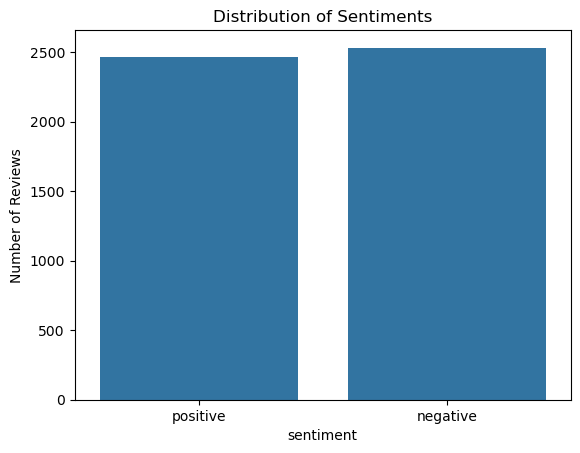

In [254]:
import matplotlib.pyplot as plt
import seaborn as sns

sns.countplot(data=df, x='sentiment')

plt.title('Distribution of Sentiments')
plt.xlabel('sentiment')
plt.ylabel('Number of Reviews')
plt.show()

In [255]:
df['sentiment'].value_counts(normalize=True) * 100

sentiment
negative    50.64
positive    49.36
Name: proportion, dtype: float64

In [256]:
df['clean_review_length'] = df['clean_review'].str.len()

C:\Users\aligs\AppData\Local\Temp\ipykernel_11172\888582502.py:1: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  df['clean_review_length'] = df['clean_review'].str.len()


In [257]:
df['word_length'] = df['filtered_tokens'].apply(len)

C:\Users\aligs\AppData\Local\Temp\ipykernel_11172\1269041128.py:1: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  df['word_length'] = df['filtered_tokens'].apply(len)


In [258]:
df


,sentiment,clean_review,filtered_tokens,clean_review_length,word_length
0,positive,one reviewers mentioned watching oz episode ho...,"[one, reviewers, mentioned, watching, oz, epis...",1237,204
1,positive,wonderful little production . filming techniqu...,"[wonderful, little, production, ., filming, te...",700,102
2,positive,thought was wonderful way spend time hot summe...,"[thought, was, wonderful, way, spend, time, ho...",633,104
3,negative,basically is family little boy jake thinks is ...,"[basically, is, family, little, boy, jake, thi...",463,76
4,positive,petter mattei 's love time money is visually s...,"[petter, mattei, 's, love, time, money, is, vi...",932,153
...,...,...,...,...,...
4995,negative,interesting slasher film multiple suspects . i...,"[interesting, slasher, film, multiple, suspect...",464,74
4996,positive,watched series first came s.i was years old wa...,"[watched, series, first, came, s.i, was, years...",1279,186
4997,positive,jet li brings charismatic presence movie scree...,"[jet, li, brings, charismatic, presence, movie...",993,161
4998,negative,rented movie hearing chris gore saying somethi...,"[rented, movie, hearing, chris, gore, saying, ...",2297,365


In [259]:
import seaborn as sns

C:\Users\aligs\AppData\Local\Temp\ipykernel_11172\3511189117.py:1: UserWarning: 

`distplot` is a deprecated function and will be removed in seaborn v0.14.0.

Please adapt your code to use either `displot` (a figure-level function with
similar flexibility) or `histplot` (an axes-level function for histograms).

For a guide to updating your code to use the new functions, please see
https://gist.github.com/mwaskom/de44147ed2974457ad6372750bbe5751

  sns.distplot(df['clean_review_length']) ## chararcter lenght


<Axes: xlabel='clean_review_length', ylabel='Density'>

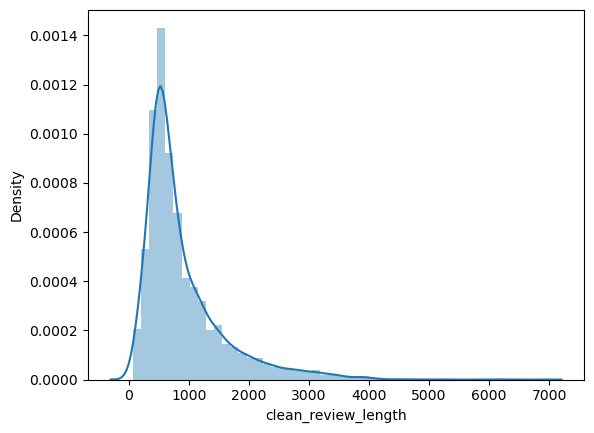

In [260]:
sns.distplot(df['clean_review_length']) ## chararcter lenght 

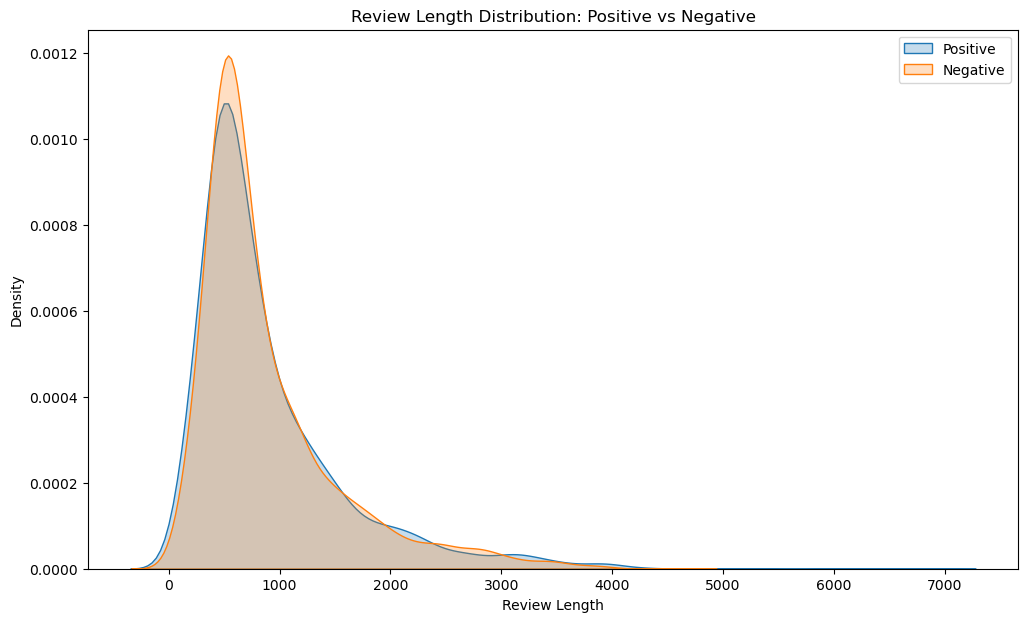

In [261]:
import seaborn as sns
import matplotlib.pyplot as plt

plt.figure(figsize=(12, 7))

sns.kdeplot(
    df[df['sentiment'] == 'positive']['clean_review_length'],
    label='Positive',
    fill=True
)

sns.kdeplot(
    df[df['sentiment'] == 'negative']['clean_review_length'],
    label='Negative',
    fill=True
)

plt.title('Review Length Distribution: Positive vs Negative')
plt.xlabel('Review Length')
plt.ylabel('Density')
plt.legend()

plt.show()

In [262]:
## this is for word length 

C:\Users\aligs\AppData\Local\Temp\ipykernel_11172\2354756712.py:1: UserWarning: 

`distplot` is a deprecated function and will be removed in seaborn v0.14.0.

Please adapt your code to use either `displot` (a figure-level function with
similar flexibility) or `histplot` (an axes-level function for histograms).

For a guide to updating your code to use the new functions, please see
https://gist.github.com/mwaskom/de44147ed2974457ad6372750bbe5751

  sns.distplot(df['word_length'])


<Axes: xlabel='word_length', ylabel='Density'>

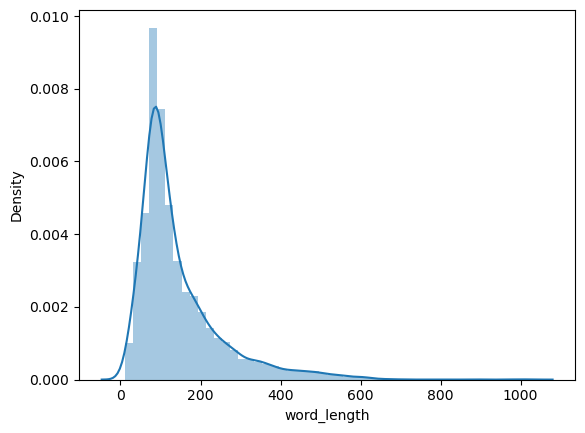

In [263]:
sns.distplot(df['word_length'])

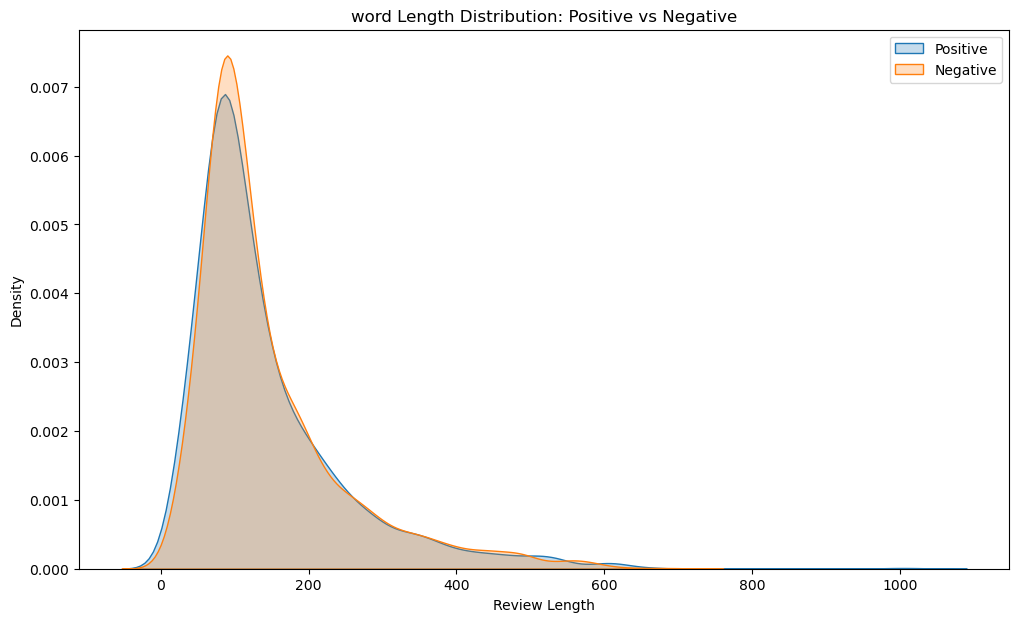

In [264]:
import seaborn as sns
import matplotlib.pyplot as plt

plt.figure(figsize=(12, 7))

sns.kdeplot(
    df[df['sentiment'] == 'positive']['word_length'],
    label='Positive',
    fill=True
)

sns.kdeplot(
    df[df['sentiment'] == 'negative']['word_length'],
    label='Negative',
    fill=True
)

plt.title('word Length Distribution: Positive vs Negative')
plt.xlabel('Review Length')
plt.ylabel('Density')
plt.legend()

plt.show()

In [265]:
df[df['sentiment'] == 'positive']

,sentiment,clean_review,filtered_tokens,clean_review_length,word_length
0,positive,one reviewers mentioned watching oz episode ho...,"[one, reviewers, mentioned, watching, oz, epis...",1237,204
1,positive,wonderful little production . filming techniqu...,"[wonderful, little, production, ., filming, te...",700,102
2,positive,thought was wonderful way spend time hot summe...,"[thought, was, wonderful, way, spend, time, ho...",633,104
4,positive,petter mattei 's love time money is visually s...,"[petter, mattei, 's, love, time, money, is, vi...",932,153
5,positive,probably time favorite movie story selflessnes...,"[probably, time, favorite, movie, story, selfl...",415,68
...,...,...,...,...,...
4989,positive,spoiler warning heard boy cried wolf legend . ...,"[spoiler, warning, heard, boy, cried, wolf, le...",836,149
4992,positive,first saw movie was freshman high school film ...,"[first, saw, movie, was, freshman, high, schoo...",561,97
4994,positive,joel schumacher made heck choice decided cast ...,"[joel, schumacher, made, heck, choice, decided...",609,99
4996,positive,watched series first came s.i was years old wa...,"[watched, series, first, came, s.i, was, years...",1279,186


In [266]:
df[df['sentiment'] == 'negative']

,sentiment,clean_review,filtered_tokens,clean_review_length,word_length
3,negative,basically is family little boy jake thinks is ...,"[basically, is, family, little, boy, jake, thi...",463,76
7,negative,show was amazing fresh innovative idea 's firs...,"[show, was, amazing, fresh, innovative, idea, ...",614,105
8,negative,encouraged positive comments film was looking ...,"[encouraged, positive, comments, film, was, lo...",453,80
10,negative,phil alien is one quirky films humour is based...,"[phil, alien, is, one, quirky, films, humour, ...",394,61
11,negative,saw movie was came . recall scariest scene was...,"[saw, movie, was, came, ., recall, scariest, s...",604,103
...,...,...,...,...,...
4991,negative,thomas edison may done lots great inventions w...,"[thomas, edison, may, done, lots, great, inven...",601,104
4993,negative,is painfully slow story last days strange dise...,"[is, painfully, slow, story, last, days, stran...",440,78
4995,negative,interesting slasher film multiple suspects . i...,"[interesting, slasher, film, multiple, suspect...",464,74
4998,negative,rented movie hearing chris gore saying somethi...,"[rented, movie, hearing, chris, gore, saying, ...",2297,365


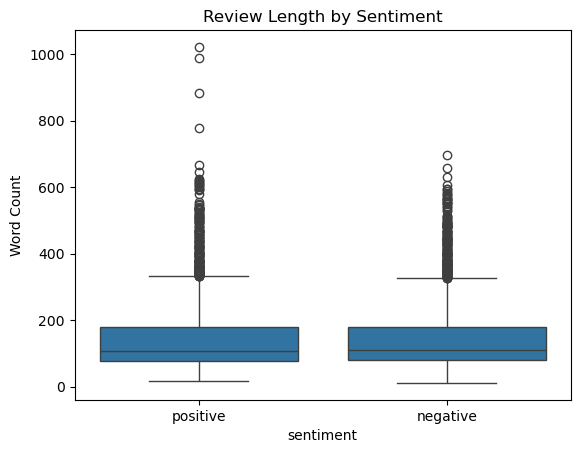

In [267]:
sns.boxplot(data=df, x='sentiment', y='word_length')

plt.title('Review Length by Sentiment')
plt.xlabel('sentiment')
plt.ylabel('Word Count')
plt.show()

In [268]:
from collections import Counter

all_words = ' '.join(df['clean_review']).split()

word_counts = Counter(all_words)

word_counts.most_common(30)

[('.', 53733),
 ('is', 27200),
 ('not', 12710),
 ('was', 10018),
 ('movie', 8932),
 ('film', 7925),
 ("'s", 7048),
 ('one', 5298),
 ('like', 4016),
 ('would', 3110),
 ('can', 3059),
 ('good', 2986),
 ('no', 2541),
 ('even', 2498),
 ('time', 2465),
 ('story', 2353),
 ('see', 2326),
 ('really', 2261),
 ('were', 2205),
 ('well', 2170),
 ("'", 2108),
 ('did', 2039),
 ('does', 2036),
 ('I', 2033),
 ('much', 1980),
 ('get', 1913),
 ('bad', 1880),
 ('...', 1875),
 ('first', 1803),
 ('could', 1785)]

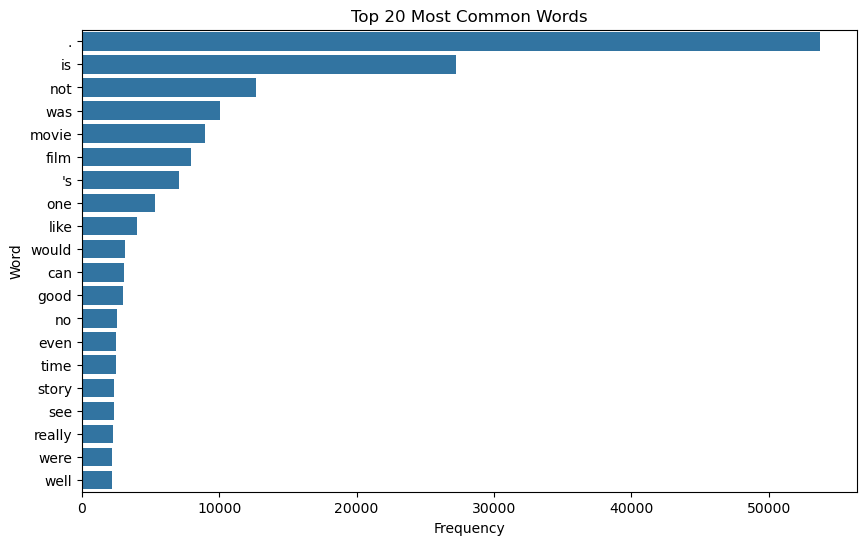

In [269]:
common_words = word_counts.most_common(20)

words = [x[0] for x in common_words]
counts = [x[1] for x in common_words]

plt.figure(figsize=(10,6))
sns.barplot(x=counts, y=words)

plt.title('Top 20 Most Common Words')
plt.xlabel('Frequency')
plt.ylabel('Word')
plt.show()

,sentiment,clean_review,filtered_tokens,clean_review_length,word_length
0,positive,one reviewers mentioned watching oz episode ho...,"[one, reviewers, mentioned, watching, oz, epis...",1192,190
1,positive,wonderful little production . filming techniqu...,"[wonderful, little, production, ., filming, te...",691,99
2,positive,thought wonderful way spend time hot summer we...,"[thought, wonderful, way, spend, time, hot, su...",601,94
3,negative,basically family little boy jake thinks zombie...,"[basically, family, little, boy, jake, thinks,...",451,72
4,positive,petter mattei 's love time money visually stun...,"[petter, mattei, 's, love, time, money, visual...",911,146
...,...,...,...,...,...
4995,negative,interesting slasher film multiple suspects . i...,"[interesting, slasher, film, multiple, suspect...",461,73
4996,positive,watched series first came s.i years old watche...,"[watched, series, first, came, s.i, years, old...",1260,181
4997,positive,jet li brings charismatic presence movie scree...,"[jet, li, brings, charismatic, presence, movie...",981,157
4998,negative,rented movie hearing chris gore saying somethi...,"[rented, movie, hearing, chris, gore, saying, ...",2254,353


In [270]:
positive_words = ' '.join(
    df[df['sentiment'] == 'positive']['clean_review']
).split()

positive_counts = Counter(positive_words)

positive_counts.most_common(20)

[('.', 26060),
 ('is', 13923),
 ('not', 5314),
 ('was', 4427),
 ('film', 4054),
 ("'s", 3939),
 ('movie', 3843),
 ('one', 2695),
 ('like', 1703),
 ('good', 1448),
 ('can', 1375),
 ('would', 1298),
 ('story', 1294),
 ('well', 1274),
 ('see', 1232),
 ('great', 1228),
 ('time', 1225),
 ("'", 1082),
 ('really', 1032),
 ('also', 1030)]

In [271]:
negative_words = ' '.join(
    df[df['sentiment'] == 'negative']['clean_review']
).split()

negative_counts = Counter(negative_words)

negative_counts.most_common(20)

[('.', 27673),
 ('is', 13277),
 ('not', 7396),
 ('was', 5591),
 ('movie', 5089),
 ('film', 3871),
 ("'s", 3109),
 ('one', 2603),
 ('like', 2313),
 ('would', 1812),
 ('can', 1684),
 ('no', 1681),
 ('even', 1609),
 ('good', 1538),
 ('bad', 1519),
 ('were', 1263),
 ('time', 1240),
 ('did', 1230),
 ('really', 1229),
 ('I', 1137)]

In [273]:
!pip install wordcloud

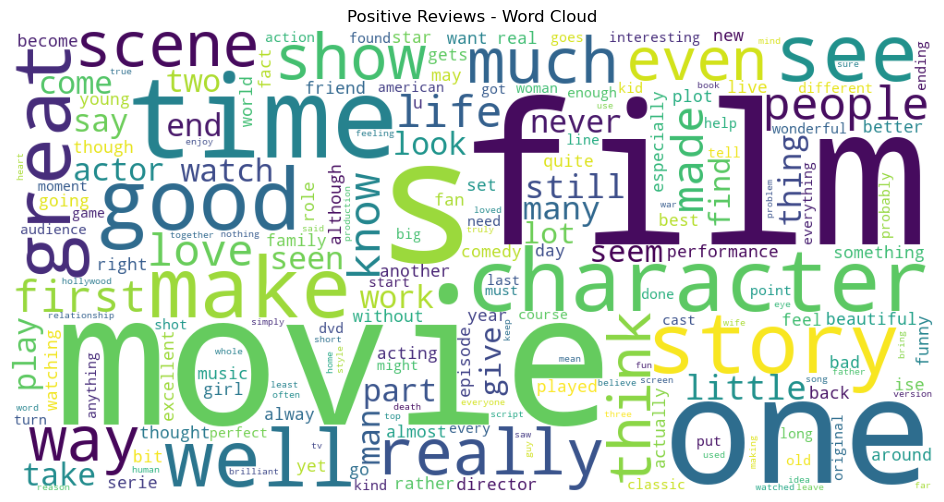

In [275]:
positive_text = ' '.join(
    df[df['sentiment'] == 'positive']['clean_review']
)

wordcloud = WordCloud(
    width=1000,
    height=500,
    background_color='white'
).generate(positive_text)

plt.figure(figsize=(12,6))
plt.imshow(wordcloud)
plt.axis('off')
plt.title('Positive Reviews - Word Cloud')
plt.show()

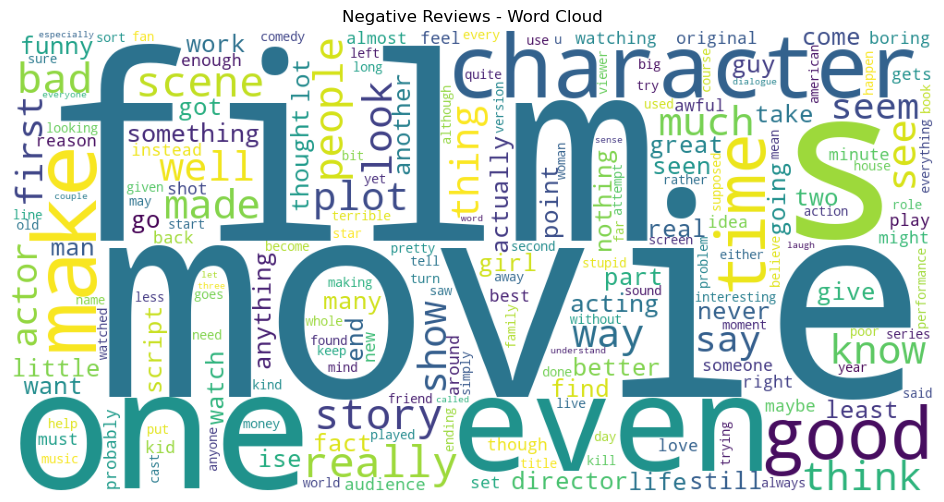

In [276]:
negative_text = ' '.join(
    df[df['sentiment'] == 'negative']['clean_review']
)

wordcloud = WordCloud(
    width=1000,
    height=500,
    background_color='white'
).generate(negative_text)

plt.figure(figsize=(12,6))
plt.imshow(wordcloud)
plt.axis('off')
plt.title('Negative Reviews - Word Cloud')
plt.show()

In [277]:
from sklearn.feature_extraction.text import CountVectorizer

In [278]:
vectorizer = CountVectorizer(
    ngram_range=(2, 2),
    max_features=20,
    stop_words='english'
)

X = vectorizer.fit_transform(df['clean_review'])

bigrams = vectorizer.get_feature_names_out()
counts = X.sum(axis=0).A1

bigram_df = pd.DataFrame({
    'bigram': bigrams,
    'count': counts
}).sort_values('count', ascending=False)

bigram_df

,bigram,count
14,special effects,235
7,low budget,192
6,looks like,178
15,waste time,172
18,year old,162
2,good movie,157
13,sci fi,145
16,watch movie,138
5,look like,137
12,real life,131


In [279]:
positive_df = df[df['sentiment'] == 'positive']
negative_df = df[df['sentiment'] == 'negative']

In [280]:
vectorizer_pos = CountVectorizer(
    ngram_range=(2, 2),
    max_features=20,
    stop_words='english'
)

X_pos = vectorizer_pos.fit_transform(positive_df['clean_review'])

pos_bigrams = pd.DataFrame({
    'bigram': vectorizer_pos.get_feature_names_out(),
    'count': X_pos.sum(axis=0).A1
}).sort_values('count', ascending=False)

pos_bigrams

,bigram,count
2,great movie,85
9,new york,79
1,good movie,78
15,special effects,75
19,years ago,71
11,real life,71
14,sci fi,70
16,watch movie,69
10,pretty good,67
0,film does,66


In [281]:
vectorizer_neg = CountVectorizer(
    ngram_range=(2, 2),
    max_features=20,
    stop_words='english'
)

X_neg = vectorizer_neg.fit_transform(negative_df['clean_review'])

neg_bigrams = pd.DataFrame({
    'bigram': vectorizer_neg.get_feature_names_out(),
    'count': X_neg.sum(axis=0).A1
}).sort_values('count', ascending=False)

neg_bigrams

,bigram,count
15,waste time,164
14,special effects,160
5,looks like,138
6,low budget,127
19,year old,99
1,bad movie,99
4,look like,97
18,worst movie,84
2,good movie,79
0,bad acting,77
